## 1. Loading Files

In [1]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

## 2. Inspecting the data

In [2]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


## 3. Summary of the data

In [3]:
orders.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


## 4. Counting unique values in each sataus column

In [4]:
orders["status"].value_counts()

status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

## 5. Removing Duplicates

In [5]:
before = len(orders)
orders = orders.drop_duplicates(subset="order_id", keep="first")
after = len(orders)
print(f"Removed {before - after} duplicate rows. Now have {after} rows.")

Removed 8 duplicate rows. Now have 500 rows.


## 6. Fixing casing and whitespaces

In [6]:
orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print(orders["city"].unique())
print(orders["category"].unique())

<StringArray>
['Pune', 'Bengaluru', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str
<StringArray>
[  'Snacks & Beverages', 'Household Essentials',               'Bakery',
        'Personal Care',  'Fruits & Vegetables',         'Dairy & Eggs']
Length: 6, dtype: str


## 7. Handling missing values

In [7]:
missing_amt = orders["amount_inr"].isna().sum()
print(f"Missing amount_inr values: {missing_amt}")

Missing amount_inr values: 10


In [8]:
clean = orders.dropna(subset=["amount_inr"]).copy()
print(f"Rows after dropping missing amount_inr: {len(clean)}")

Rows after dropping missing amount_inr: 490


### Rating is null for Cancelled/Pending orders only — left unfilled intentionally, since this reflects orders that were never actually rated, not a data quality issue.

In [9]:
print(clean["rating"].isna().sum())
print(clean.loc[clean["rating"].isna(), "status"].unique())

65
<StringArray>
['Pending', 'Cancelled']
Length: 2, dtype: str


## 8. IQR outlier detection and capping

In [10]:
delivered_mask = clean["status"] == "Delivered"

Q1 = clean.loc[delivered_mask, "amount_inr"].quantile(0.25)
Q3 = clean.loc[delivered_mask, "amount_inr"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

capped_count = (clean.loc[delivered_mask, "amount_inr"] > upper_fence).sum()
clean.loc[delivered_mask, "amount_inr"] = clean.loc[delivered_mask, "amount_inr"].clip(upper=upper_fence)

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}, upper fence = {upper_fence}")
print(f"Capped {capped_count} rows")

Q1 = 90.0, Q3 = 275.0, IQR = 185.0, upper fence = 552.5
Capped 16 rows


## 9. Derived columns

In [11]:
clean["order_date"] = pd.to_datetime(clean["order_date"])
clean["month"] = clean["order_date"].dt.month
clean["month_name"] = clean["order_date"].dt.month_name()
clean["revenue_per_unit"] = clean["amount_inr"] / clean["quantity"]
clean["is_delivered"] = clean["status"] == "Delivered"

clean.head()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit,is_delivered
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,3,March,35.0,True
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,5,May,60.0,True
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,6,June,75.0,True
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,3,March,30.0,True
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,4,April,110.0,True


### Top category by revenue

In [12]:
delivered_clean = clean[clean["is_delivered"]]
cat_revenue = delivered_clean.groupby("category")["amount_inr"].sum().sort_values(ascending=False)
print(cat_revenue)

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64


### Top supplier (merge with products.csv)

In [13]:
merged = delivered_clean.merge(products[["product_id", "supplier"]], on="product_id", how="left")
supplier_revenue = merged.groupby("supplier")["amount_inr"].sum().sort_values(ascending=False)
print(supplier_revenue)

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64


### Explicit cross-validation statement

In [14]:
top_category = cat_revenue.index[0]
top_supplier = supplier_revenue.index[0]

print("Top category:", top_category)
print("Top supplier:", top_supplier)
print("Matches Part 1 top category (Household Essentials)?", top_category == "Household Essentials")
print("Matches Part 1 top supplier (HomeEssentials Traders)?", top_supplier == "HomeEssentials Traders")

Top category: Household Essentials
Top supplier: HomeEssentials Traders
Matches Part 1 top category (Household Essentials)? True
Matches Part 1 top supplier (HomeEssentials Traders)? True


## 9. Data Visualizations
### Chart 1 — Category revenue bar chart:

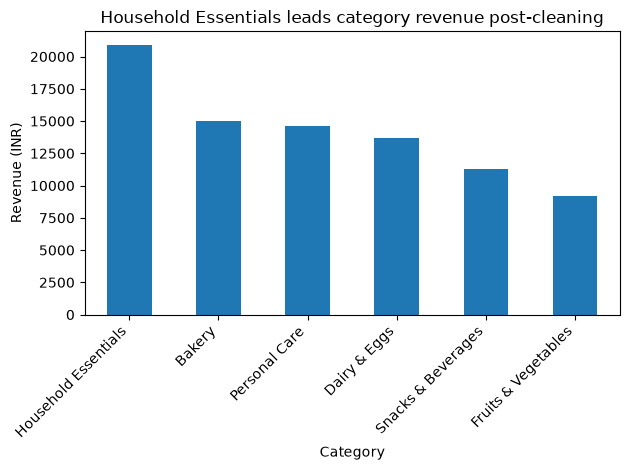

In [15]:
import matplotlib.pyplot as plt

cat_revenue.plot(kind="bar", title="Household Essentials leads category revenue post-cleaning")
plt.ylabel("Revenue (INR)")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Chart 2 — Monthly revenue trend (Delivered only):

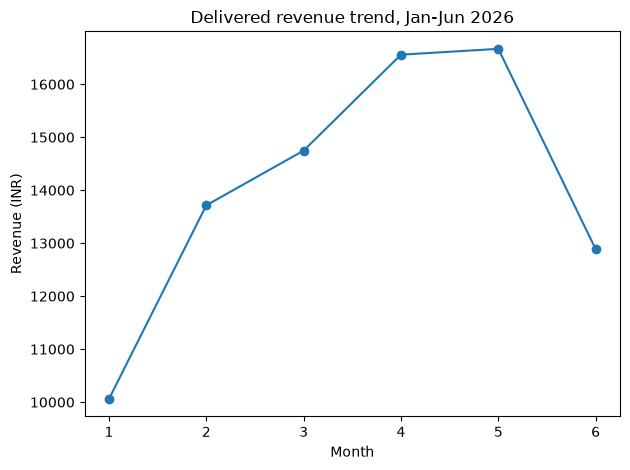

In [16]:
monthly_trend = delivered_clean.groupby("month")["amount_inr"].sum()
monthly_trend.plot(kind="line", marker="o", title="Delivered revenue trend, Jan-Jun 2026")
plt.ylabel("Revenue (INR)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

### Chart 3 - Top supplier

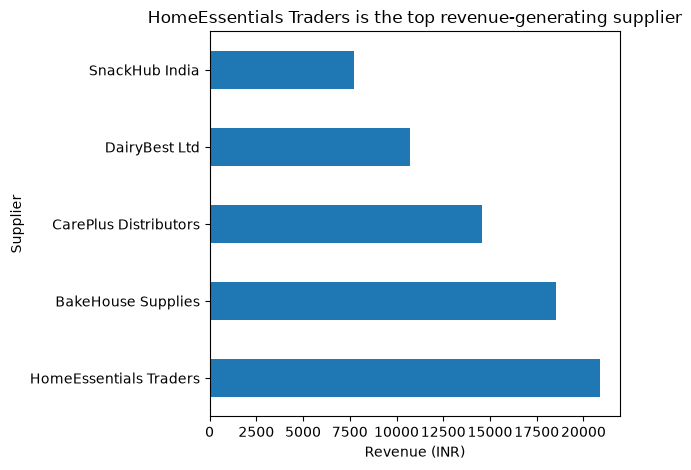

In [17]:
supplier_revenue.head(5).plot(kind="barh", title="HomeEssentials Traders is the top revenue-generating supplier")
plt.xlabel("Revenue (INR)")
plt.ylabel("Supplier")
plt.tight_layout()
plt.show()

# Observations

## 1. Household Essentials, bigbasket's greatest strength
- **Key Point:** Household Essentials was bigbasket's top category at a high 20,910 Delivered - over 40% above next best category, Bakery (14,975).

- **Takeaway:** Based on this segment of the SQL table, Household Essentials is bigbasket's biggest revenue source in this dataset. Same goes for the clean, separate Pandas table (Part 4). Robustness of the result increases confidence.

- **Next Step:** Understand "why" Household Essentials performs so well (e.g. Repeat-purchase rate, breadth of offerings), so learn whether this operational approach can be used to improve underperforming categories.

## 2. Trends in Revenue - up in May, dropping in June
- **Key Point:** Monthly Delivered revenue rose steadily from ₹10,059.5 in January to a peak of ₹16,668.5 in May, then dropped to ₹12,888.0 in June — roughly a 23% month-over-month decline.

- **Takeaway:** A single-month drop after four consecutive months of growth is worth flagging early, since it could indicate a seasonal dip, a stocking issue, or a short-term demand shift rather than a sustained trend — but with only 6 months of data, it's too early to say which.

- **Next step:** Pull July data once available to see if June was a one-off dip or the start of a declining trend, and check whether the drop is concentrated in specific categories or spread evenly.

## 3. Distribution of Revenue - dominated by Home Essentials Traders & Household Essentials
- **Key Point:** Home Essentials Traders generated the same revenue (20,910) as Household Essentials, which fell into a tie for first place among all suppliers and the Number 1 spot among suppliers for that category. That is, these two factors seem related.

- **Takeaway:** Over-reliance on one key supplier for Category revenue can be risky. Confirm whether this retailer is on track for its current fulfillment forecast for this supplier, and consider adding a second supplier.